# Tree-Based Model: Random Forest (Retention Prediction)

**Goal:** predict next-year retention (`RetainedLabel` = `Retained` vs `Churned`) using a tree-based model, evaluate it (accuracy / precision / recall / AUC), tune hyperparameters, and generate the required `prediction_submission.csv`.


In [1]:
import os
import zipfile
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt


## 1) Load data (labeled + unlabeled)

If you uploaded the zip (`classification_project_files-1.zip`) into Colab or your working directory, this will extract it and load the CSVs.


In [2]:
# --- If the zip exists locally, extract it ---
ZIP_PATH = "classification_project_files-1.zip"
EXTRACT_DIR = "classification_project_files"

if os.path.exists(ZIP_PATH) and not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(".")

# --- Preferred local paths (after extracting the zip) ---
DATA_PATH_LOCAL = os.path.join(EXTRACT_DIR, "scholastic_travel.csv")
PRED_PATH_LOCAL = os.path.join(EXTRACT_DIR, "scholastic_travel_predictions.csv")

# --- Fallback: instructor dropbox links (only used if local files are missing) ---
DATA_PATH_FALLBACK = "https://www.dropbox.com/scl/fi/hsh5kfc52hv57pkjq3crp/scholastic_travel.csv?rlkey=lzmscfrwl7wfrlgxdhc469zss&dl=1"
PRED_PATH_FALLBACK = "https://www.dropbox.com/scl/fi/hveyqinjaurpm2e1s5uh2/scholastic_travel_predictions.csv?rlkey=3sx0cjmaubjafwripmcsfhktd&dl=1"

DATA_PATH = DATA_PATH_LOCAL if os.path.exists(DATA_PATH_LOCAL) else DATA_PATH_FALLBACK
PRED_PATH = PRED_PATH_LOCAL if os.path.exists(PRED_PATH_LOCAL) else PRED_PATH_FALLBACK

df_raw = pd.read_csv(DATA_PATH)
df_pred_raw = pd.read_csv(PRED_PATH)

print("Labeled data shape:", df_raw.shape)
print("Unlabeled data shape:", df_pred_raw.shape)
df_raw.head()


Labeled data shape: (2389, 55)
Unlabeled data shape: (479, 55)


,ProgramCode,FromGrade,ToGrade,GroupState,IsNonAnnual,Days,TravelType,DepartureDate,ReturnDate,DepositDate,...,GroupGradeTypeLow,GroupGradeTypeHigh,GroupGradeType,MajorProgramCode,SingleGradeTripFlag,FPPtoSchoolenrollment,FPPtoPAX,NumofNonFPPPAX,SchoolSizeIndicator,RetainedLabel
0,HS,4,4,CA,0,1,A,1/14/11,1/14/11,8/30/10,...,K,Elementary,K->Elementary,H,1,0.063646,0.936508,4,L,Retained
1,HC,8,8,AZ,0,7,A,1/14/11,1/21/11,11/15/09,...,Middle,Middle,Middle->Middle,H,1,0.025882,0.880000,3,L,Retained
2,HD,8,8,FL,0,3,A,1/15/11,1/17/11,10/15/10,...,Middle,Middle,Middle->Middle,H,1,0.025131,0.888889,3,L,Retained
3,HN,9,12,Other,1,3,B,1/15/11,1/17/11,1/7/11,...,Undefined,Undefined,Undefined->Undefined,H,0,0.000000,1.000000,0,FIXED_NA,Churned
4,HD,6,8,FL,0,6,Other,1/16/11,1/21/11,9/30/10,...,Middle,Middle,Middle->Middle,H,0,0.112500,0.910112,8,M-L,Churned


## 2) Feature engineering

Random forests can handle lots of predictors, including one-hot-encoded categoricals.

Feature engineering used here:
- Parse date columns and extract **month / day-of-week / year**
- Create time deltas like **days_to_departure**, **planning_window**, **meeting_span**
- Add **grade_range** (`ToGrade - FromGrade`)
- Add simple rates: `discount_pax_rate`, `cancel_pax_rate`, `fpp_rate`
- Drop raw datetime columns after creating numeric features


In [3]:
def feature_engineer(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    date_cols = [
        "DepartureDate", "ReturnDate", "DepositDate",
        "EarlyRPL", "LatestRPL", "InitialSystemDate",
        "FirstMeeting", "LastMeeting"
    ]

    # Parse to datetime + extract components
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], format="%m/%d/%y", errors="coerce")
            df[f"{col}_month"] = df[col].dt.month
            df[f"{col}_dow"] = df[col].dt.dayofweek
            df[f"{col}_year"] = df[col].dt.year

    # Time deltas
    if {"DepartureDate", "DepositDate"}.issubset(df.columns):
        df["days_to_departure"] = (df["DepartureDate"] - df["DepositDate"]).dt.days
    if {"DepartureDate", "InitialSystemDate"}.issubset(df.columns):
        df["planning_window"] = (df["DepartureDate"] - df["InitialSystemDate"]).dt.days
    if {"LastMeeting", "FirstMeeting"}.issubset(df.columns):
        df["meeting_span"] = (df["LastMeeting"] - df["FirstMeeting"]).dt.days
    if {"FirstMeeting", "DepositDate"}.issubset(df.columns):
        df["deposit_to_first_meeting"] = (df["FirstMeeting"] - df["DepositDate"]).dt.days
    if {"ReturnDate", "DepartureDate"}.issubset(df.columns):
        df["trip_length_from_dates"] = (df["ReturnDate"] - df["DepartureDate"]).dt.days

    # Grade range
    if {"ToGrade", "FromGrade"}.issubset(df.columns):
        df["grade_range"] = df["ToGrade"] - df["FromGrade"]

    # Simple rates (guard division by zero)
    if {"TotalDiscountPax", "TotalPax"}.issubset(df.columns):
        denom = df["TotalPax"].replace(0, np.nan)
        df["discount_pax_rate"] = df["TotalDiscountPax"] / denom

    if {"CancelledPax", "TotalPax"}.issubset(df.columns):
        denom = df["TotalPax"].replace(0, np.nan)
        df["cancel_pax_rate"] = df["CancelledPax"] / denom

    if {"FPP", "TotalPax"}.issubset(df.columns):
        denom = df["TotalPax"].replace(0, np.nan)
        df["fpp_rate"] = df["FPP"] / denom

    # Drop raw datetime columns (keep engineered numeric components)
    for col in date_cols:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    return df


df = feature_engineer(df_raw)

# Target: Retained = 1 (positive class), Churned = 0
y = df_raw["RetainedLabel"].map({"Retained": 1, "Churned": 0})
X = df.drop(columns=["RetainedLabel"], errors="ignore")

print("X shape after feature engineering:", X.shape)
y.value_counts()


X shape after feature engineering: (2389, 79)


,count
RetainedLabel,
1,1451
0,938


## 3) Train/test split + preprocessing pipeline

We use a `ColumnTransformer` so:
- numeric columns → median imputation
- categorical columns → most-frequent imputation + one-hot encoding (`handle_unknown="ignore"`)


In [4]:
# Identify categorical vs numeric predictors
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (1911, 79) Test: (478, 79)


## 4) Utility: evaluate metrics

We report:
- **Accuracy**
- **Precision** (for *Retained* class)
- **Recall** (for *Retained* class)
- **AUC** (ROC-AUC; uses predicted probabilities)


In [5]:
def evaluate_binary(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_proba),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }


## 5) Baseline Random Forest

A solid baseline for tabular classification is:

- `n_estimators=300`
- `class_weight="balanced_subsample"` (helps if classes are imbalanced)
- `max_features="sqrt"`


In [6]:
baseline_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_features="sqrt",
)

baseline_model = Pipeline([
    ("preprocess", preprocess),
    ("rf", baseline_rf)
])

baseline_model.fit(X_train, y_train)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]
baseline_metrics = evaluate_binary(y_test, baseline_proba)

baseline_metrics


{'accuracy': 0.8138075313807531,
 'precision': 0.8361204013377926,
 'recall': 0.8620689655172413,
 'auc': np.float64(0.8615278796771826),
 'confusion_matrix': array([[139,  49],
        [ 40, 250]])}

## 6) Hyperparameter tuning (small manual log)

Instead of an expensive CV search, this runs **7** reasonable parameter sets quickly and logs test-set metrics.

You can add more rows/configurations if you want (e.g., vary `max_depth`, `min_samples_leaf`, `max_features`).


In [7]:
configs = [
    {"config":"baseline_balanced", "n_estimators":300, "max_depth":None, "min_samples_leaf":1, "min_samples_split":2, "max_features":"sqrt", "bootstrap":True, "class_weight":"balanced_subsample"},
    {"config":"depth12_leaf2",     "n_estimators":300, "max_depth":12,   "min_samples_leaf":2, "min_samples_split":4, "max_features":"sqrt", "bootstrap":True, "class_weight":"balanced_subsample"},
    {"config":"more_regularized",  "n_estimators":300, "max_depth":10,   "min_samples_leaf":5, "min_samples_split":10,"max_features":"sqrt", "bootstrap":True, "class_weight":"balanced_subsample"},
    {"config":"unweighted",        "n_estimators":300, "max_depth":None, "min_samples_leaf":1, "min_samples_split":2, "max_features":"sqrt", "bootstrap":True, "class_weight":None},
    {"config":"log2_features",     "n_estimators":250, "max_depth":None, "min_samples_leaf":1, "min_samples_split":2, "max_features":"log2", "bootstrap":True, "class_weight":"balanced_subsample"},
    {"config":"half_features",     "n_estimators":250, "max_depth":None, "min_samples_leaf":1, "min_samples_split":2, "max_features":0.5,    "bootstrap":True, "class_weight":"balanced_subsample"},
    {"config":"no_bootstrap",      "n_estimators":250, "max_depth":None, "min_samples_leaf":1, "min_samples_split":2, "max_features":"sqrt", "bootstrap":False,"class_weight":"balanced_subsample"},
]

rows = []
for cfg in configs:
    rf = RandomForestClassifier(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        min_samples_split=cfg["min_samples_split"],
        min_samples_leaf=cfg["min_samples_leaf"],
        max_features=cfg["max_features"],
        bootstrap=cfg["bootstrap"],
        class_weight=cfg["class_weight"],
        random_state=42,
        n_jobs=-1
    )

    model = Pipeline([("preprocess", preprocess), ("rf", rf)])
    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:, 1]
    m = evaluate_binary(y_test, proba)

    rows.append({
        **cfg,
        "accuracy": m["accuracy"],
        "precision": m["precision"],
        "recall": m["recall"],
        "auc": m["auc"],
    })

rf_log = pd.DataFrame(rows).sort_values("accuracy", ascending=False)
rf_log


,config,n_estimators,max_depth,min_samples_leaf,min_samples_split,max_features,bootstrap,class_weight,accuracy,precision,recall,auc
5,half_features,250,NaN,1,2,0.5,True,balanced_subsample,0.817992,0.830619,0.879310,0.868048
3,unweighted,300,NaN,1,2,sqrt,True,None,0.815900,0.843537,0.855172,0.863756
6,no_bootstrap,250,NaN,1,2,sqrt,False,balanced_subsample,0.815900,0.843537,0.855172,0.859950
0,baseline_balanced,300,NaN,1,2,sqrt,True,balanced_subsample,0.813808,0.836120,0.862069,0.861528
4,log2_features,250,NaN,1,2,log2,True,balanced_subsample,0.811715,0.831126,0.865517,0.855163
1,depth12_leaf2,300,12.0,2,4,sqrt,True,balanced_subsample,0.799163,0.839161,0.827586,0.860216
2,more_regularized,300,10.0,5,10,sqrt,True,balanced_subsample,0.782427,0.839416,0.793103,0.857080


## 7) Fit the best RF + inspect confusion matrix and feature importance

We’ll pick the best row by **accuracy** from `rf_log`, refit it, then:
- show confusion matrix
- plot top importances (from `feature_importances_`)


In [8]:
# Pick best hyperparameters by test accuracy (from the log above)
best_row = rf_log.iloc[0].to_dict()
best_row


{'config': 'half_features',
 'n_estimators': 250,
 'max_depth': nan,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'max_features': 0.5,
 'bootstrap': True,
 'class_weight': 'balanced_subsample',
 'accuracy': 0.8179916317991632,
 'precision': 0.8306188925081434,
 'recall': 0.8793103448275862,
 'auc': 0.868048422597212}

In [9]:
best_rf = RandomForestClassifier(
    n_estimators=int(best_row["n_estimators"]),
    max_depth=None if pd.isna(best_row["max_depth"]) else int(best_row["max_depth"]),
    min_samples_split=int(best_row["min_samples_split"]),
    min_samples_leaf=int(best_row["min_samples_leaf"]),
    max_features=best_row["max_features"],
    bootstrap=bool(best_row["bootstrap"]),
    class_weight=best_row["class_weight"],
    random_state=42,
    n_jobs=-1
)

best_model = Pipeline([
    ("preprocess", preprocess),
    ("rf", best_rf)
])

best_model.fit(X_train, y_train)
best_proba = best_model.predict_proba(X_test)[:, 1]
best_metrics = evaluate_binary(y_test, best_proba)

best_metrics


{'accuracy': 0.8179916317991632,
 'precision': 0.8306188925081434,
 'recall': 0.8793103448275862,
 'auc': np.float64(0.868048422597212),
 'confusion_matrix': array([[136,  52],
        [ 35, 255]])}

In [10]:
cm = best_metrics["confusion_matrix"]
cm


array([[136,  52],
       [ 35, 255]])

,feature,importance
22,SingleGradeTripFlag,0.113937
55,grade_range,0.081060
2,IsNonAnnual,0.064375
129,SPRNewExisting_EXISTING,0.036963
16,FPP,0.036643
130,SPRNewExisting_NEW,0.031506
51,planning_window,0.030291
17,TotalPax,0.029754
13,TotalSchoolEnrollment,0.026536
53,deposit_to_first_meeting,0.024043


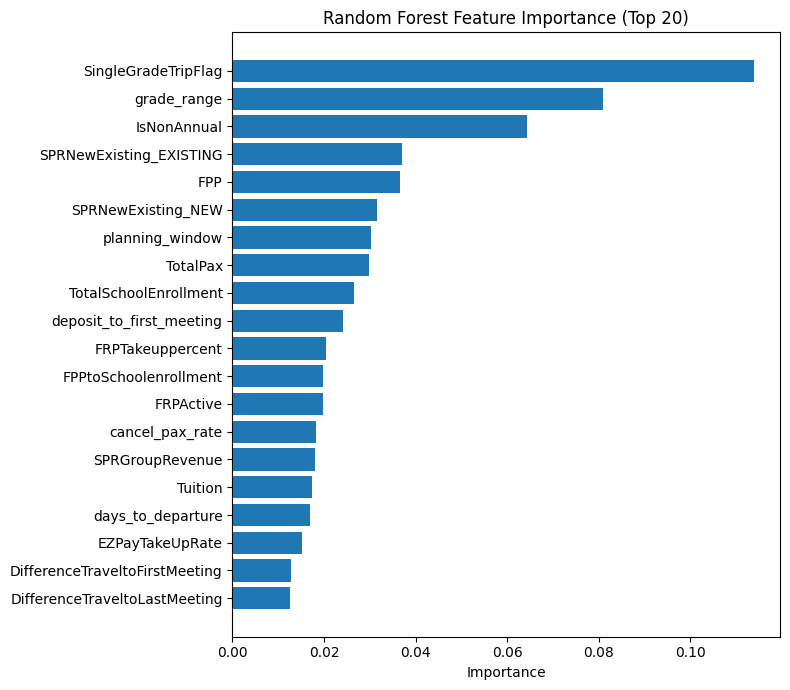

In [11]:
# ---- Feature importance (top 20) ----
pre = best_model.named_steps["preprocess"]
ohe = pre.named_transformers_["cat"].named_steps["onehot"]

feature_names = np.concatenate([
    np.array(num_cols, dtype=object),
    ohe.get_feature_names_out(cat_cols)
])

importances = best_model.named_steps["rf"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

top_k = 20
display(imp_df.head(top_k))

plt.figure(figsize=(8, 7))
plt.barh(imp_df.head(top_k)["feature"][::-1], imp_df.head(top_k)["importance"][::-1])
plt.title("Random Forest Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 8) Generate `prediction_submission.csv`

**Important:** to maximize leaderboard/class accuracy, we refit the chosen model on **ALL labeled data** before predicting the unlabeled file.


In [12]:
# Refit on ALL labeled data (recommended before producing submission)
best_model.fit(X, y)

# Feature engineer unlabeled data the same way
df_pred = feature_engineer(df_pred_raw)
X_pred = df_pred.drop(columns=["RetainedLabel"], errors="ignore")

pred_proba = best_model.predict_proba(X_pred)[:, 1]
pred_label = np.where(pred_proba >= 0.5, "Retained", "Churned")

prediction_submission = pd.DataFrame({"RetainedLabel": pred_label})
prediction_submission.head()


,RetainedLabel
0,Retained
1,Churned
2,Retained
3,Retained
4,Retained


In [13]:
# Write the required file
OUT_PATH = "prediction_submission.csv"
prediction_submission.to_csv(OUT_PATH, index=False)

print("Wrote:", OUT_PATH)
print(prediction_submission["RetainedLabel"].value_counts())


Wrote: prediction_submission.csv
RetainedLabel
Retained    291
Churned     188
Name: count, dtype: int64
